# 05_统计检验方法-F检验

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天咱们首先来全面介绍 F 检验。

简单来说，F 检验（F-test）是一种用于比较两个样本总体的方差是否存在显著差异的统计方法。它广泛应用于多个统计分析领域，如回归分析、方差分析（ANOVA）和多元统计方法中。

F 检验的基本思想是利用 F 分布来判断两个样本数据组的方差是否存在显著差异。

直观的说，我们可以设想在实际问题中，两个独立的样本分别来自两个总体，这两个总体可能具有不同的离散程度（即方差）。

F 检验通过计算两个样本方差的比值，来检验两个总体方差是否相等。

- 如果两个样本的方差差异不大，那么计算出来的比值会接近 1。
- 如果存在显著差异，那么比值会明显偏离 1。

### 一个直观的例子

未来的你是一位农业科学家，想比较两种不同肥料对作物产量波动的影响。

你对两块试验田分别施用了肥料 A 和肥料 B，记录了各自的作物产量。

现在你希望检验这两种肥料是否在产量的波动性（即方差）上有显著差别。

- **步骤一**：计算两块试验田的样本方差。
- **步骤二**：计算方差比值（较大方差除以较小方差），这个比值服从 F 分布。
- **步骤三**：利用 F 分布表或统计软件得到 p 值，从而判断差异是否显著。

如果 p 值低于预设的显著性水平（例如 0.05），则说明两种肥料对产量波动的影响存在显著差异，否则认为差异不显著。

### 检验的本质和特点

F 检验的本质在于比较两个样本数据集的方差，并判断它们是否来自于具有相同方差的总体。它基于两个独立的正态分布总体样本，通过计算样本方差比值，利用 F 分布的理论进行统计推断。

**特点：**

1. **非负性**：由于是两个正方差的比值，F 检验统计量必然是非负的。
2. **偏态分布**：F 分布是一个偏态分布，特别是在自由度较小时，其分布形态会明显偏右。
3. **依赖自由度**：F 分布的形状与两个样本的自由度密切相关。
4. **用途广泛**：不仅在检验方差是否相等中有重要应用，同时在方差分析（ANOVA）、回归分析、以及多变量分析中也经常出现。

## 直观理解

为了更直观地理解 F 分布及 F 检验的统计特性，我们可以使用图形来展示 F 分布的形状和特征。

### F 分布的基本形状

F 分布是由两个卡方分布（χ² 分布）按一定比例构成的比值分布。其概率密度函数形状取决于两个自由度参数 $d_1$和 $d_2$（分别对应分子和分母的自由度）。

通常，F 分布具有如下特征：

- 当 $d_1$和 $d_2$都较大时，F 分布趋近于正态分布，但始终保持非负性。
- 当自由度较小（尤其是分子自由度较小）时，分布呈现较强的右偏。
- 分布的形状会随着自由度的变化而发生明显变化，高自由度时曲线更平滑，低自由度时峰度较高且尾部较长。

### 图形示例

下面的图示展示了不同自由度组合下的 F 分布曲线：

> 我们展示了几组典型的自由度组合（例如 $d_1=5, d_2=10$和 $d_1=10, d_2=20$等）的 F 分布概率密度函数。

- 横轴表示 F 检验统计量的取值（大于等于 0）。
- 纵轴表示对应的概率密度值。

> 通过观察不同自由度下的曲线，可以看到当自由度增大时，分布曲线更平滑且峰值较低，而自由度较小时，曲线右偏明显。

在最后，使用 Python 绘制 F 分布图的示例代码（详细代码见后续部分），生成的图表将直观展示 F 分布的形状和特征。

## 公式推导

为了深入理解 F 检验，我们需要从数学原理上推导 F 分布的概率密度函数及其相关公式。

这里主要涉及两个独立的卡方分布的比值。

### 基本假设

假设有两个独立的随机变量 $U$和 $V$，其中：

$U \sim \chi^2_{d_1}$（服从自由度为 $d_1$的卡方分布）

$V \sim \chi^2_{d_2}$（服从自由度为 $d_2$的卡方分布）

定义 F 检验统计量为  
$F = \frac{U/d_1}{V/d_2}$  
该统计量服从自由度为 $d_1$和 $d_2$的 F 分布，即 $F \sim F(d_1, d_2)$。

### 概率密度函数推导

F 分布的概率密度函数（pdf）可写为：


$$
f_F(x; d_1, d_2) = \frac{\Gamma\left(\frac{d_1+d_2}{2}\right)}{\Gamma\left(\frac{d_1}{2}\right)\Gamma\left(\frac{d_2}{2}\right)} \left(\frac{d_1}{d_2}\right)^{\frac{d_1}{2}} x^{\frac{d_1}{2}-1} \left(1+\frac{d_1}{d_2} x\right)^{-\frac{d_1+d_2}{2}}, \quad x>0.
$$


#### 推导步骤

1. **起始点**：首先利用卡方分布的概率密度函数。对于卡方分布 $\chi^2_k$，其 pdf 为  
$f_{\chi^2}(y; k) = \frac{1}{2^{k/2}\Gamma(k/2)} y^{k/2-1} e^{-y/2}, \quad y > 0.$
2. **构造比值变量**：令 $U$和 $V$分别为两个独立的卡方变量，考虑比值  
$F = \frac{U/d_1}{V/d_2}.$  
我们需要求 $F$的分布。
3. **变量变换**：利用联合分布的变换方法，先写出 $U$与 $V$的联合概率密度函数，然后通过 Jacobian 变换求出新变量 $(F, V)$的联合分布，再将 $V$积分掉即可得到 $F$的边缘分布。
4. **积分运算**：经过一定的积分运算与变量替换，最后可以得到 F 分布的概率密度函数的标准形式。该过程会用到伽玛函数（Gamma 函数）的性质以及积分公式。
5. **结果表达**：经过化简，最终可以将 F 分布的密度函数表示为上面给出的公式形式。

#### 伽玛函数

伽玛函数 $\Gamma(z)$ 是一个在复平面上定义的函数，其定义为：  
$\Gamma(z) = \int_0^\infty t^{z-1}e^{-t} \, dt, \quad \Re(z) > 0.$  
伽玛函数在很多统计分布的推导中起到了关键作用，比如卡方分布、t 分布、F 分布等。尤其在 F 分布公式中，多个伽玛函数相互结合，确保了密度函数在整个定义域上的积分为 1。

### 推导过程中的关键点

- **自由度的影响**：公式中的 $d_1$和 $d_2$显示了两个独立卡方分布的自由度对 F 分布形状的影响。自由度越大，分布越平滑。
- **比例关系**：比值中分子和分母分别除以自由度，保证了当两个总体方差相等时，F 统计量的期望值接近 1。
- **伽玛函数的应用**：伽玛函数帮助将积分问题转化为已知形式，从而求出标准化常数。

## 代码实现

我们利用 Python 展示如何生成用于方差分析的数据，并通过代码示例对 F 检验进行可视化和分析。

我们会分为两部分：一部分用于模拟数据并绘制 F 分布图；另一部分展示如何利用 F 检验在方差分析中的机器学习应用。

### 模拟数据与 F 分布可视化

首先，我们生成一些服从正态分布的数据，并模拟两组数据的方差差异。然后，计算两组样本方差的比值，并绘制对应的 F 分布曲线。

样本方差 A: 0.8100, 样本方差 B: 3.4678
F 统计量: 4.2812


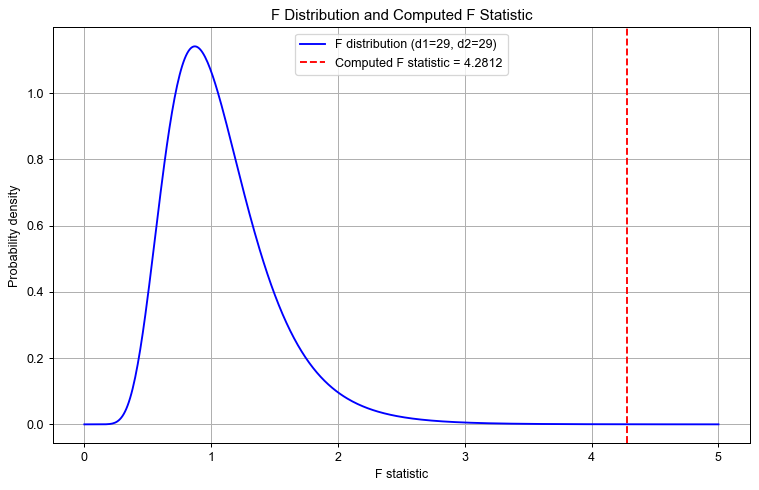

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

## 设定随机种子，确保结果可重复
np.random.seed(42)

## 生成两组正态分布数据
## 假设组 A 的数据服从 N(0, 1) 分布，组 B 的数据服从 N(0, 2^2) 分布
n_A, n_B = 30, 30  # 样本容量
data_A = np.random.normal(loc=0, scale=1, size=n_A)
data_B = np.random.normal(loc=0, scale=2, size=n_B)

## 计算样本方差
var_A = np.var(data_A, ddof=1)
var_B = np.var(data_B, ddof=1)

## 计算 F 统计量（较大方差除以较小方差）
F_stat = var_B / var_A if var_B >= var_A else var_A / var_B
print("样本方差 A: {:.4f}, 样本方差 B: {:.4f}".format(var_A, var_B))
print("F 统计量: {:.4f}".format(F_stat))

## 自由度
d1 = n_B - 1 if var_B >= var_A else n_A - 1
d2 = n_A - 1 if var_B >= var_A else n_B - 1

## 生成 F 分布的 x 值
x = np.linspace(0, 5, 500)
pdf = stats.f.pdf(x, dfn=d1, dfd=d2)

## 绘制 F 分布图
plt.figure(figsize=(10, 6))
plt.plot(x, pdf, label='F distribution (d1={}, d2={})'.format(d1, d2), color='blue')
plt.axvline(F_stat, color='red', linestyle='--', label='Computed F statistic = {:.4f}'.format(F_stat))
plt.xlabel('F statistic')
plt.ylabel('Probability density')
plt.title('F Distribution and Computed F Statistic')
plt.legend()
plt.grid(True)
plt.show()

- **数据生成**：我们分别生成两组正态分布数据，组 A 标准差为 1，组 B 标准差为 2，从而使得两组数据具有不同的方差。
- **样本方差计算**：利用 `np.var` 并设定 `ddof=1` 来计算无偏估计的样本方差。
- **F 统计量计算**：较大方差除以较小方差，确保 F 值大于等于 1。
- **F 分布曲线绘制**：利用 `scipy.stats.f.pdf` 生成 F 分布的概率密度函数，并绘制计算的 F 统计量位置。

![原文参考图，当前结果见代码输出](attachments/img_021.png)

通过上述代码，我们可以直观地看到生成的 F 分布曲线，以及计算的 F 统计量在该曲线上的位置，到这里大家应该就会很清楚的理解其中的原理。

### 方差分析（ANOVA）机器学习应用

在机器学习中，方差分析常用于特征选择和模型评估。例如，我们可以利用 F 检验判断不同特征对目标变量解释能力的显著性，从而筛选出最重要的特征。

这里给出的例子：利用 ANOVA F 检验进行特征选择。

假设我们有一个数据集，其中包含多个特征和一个连续型的目标变量。我们希望通过 ANOVA F 检验来确定哪些特征对目标变量有显著影响，然后仅保留这些特征用于后续的机器学习模型训练。

#### 实现步骤

1. **数据预处理**：载入数据并对数据进行清洗和标准化。
2. **F 检验计算**：对于每个特征，利用 ANOVA F 检验计算 F 值和 p 值。
3. **特征选择**：设定一个显著性水平（例如 0.05），筛选出 p 值小于该水平的特征。
4. **模型训练**：利用筛选后的特征进行机器学习模型（如线性回归、决策树等）的训练和评估。

下面，咱们利用 `scikit-learn` 中的 `f_regression` 函数进行 ANOVA F 检验，并进行特征选择：

ANOVA F 检验结果:
     Feature     F_value       p_value
3  feature_3  375.241482  8.142749e-69
6  feature_6  301.884991  1.354324e-57
9  feature_9  220.041644  3.821094e-44
2  feature_2   46.825589  1.546095e-11
1  feature_1   35.293143  4.233251e-09
0  feature_0   29.771735  6.489093e-08
5  feature_5   10.009880  1.616030e-03
7  feature_7    8.442624  3.766644e-03
4  feature_4    3.490408  6.209160e-02
8  feature_8    0.419955  5.171459e-01

显著的特征: ['feature_3', 'feature_6', 'feature_9', 'feature_2', 'feature_1', 'feature_0', 'feature_5', 'feature_7']

使用筛选后特征的模型 R^2 分数: 0.9903


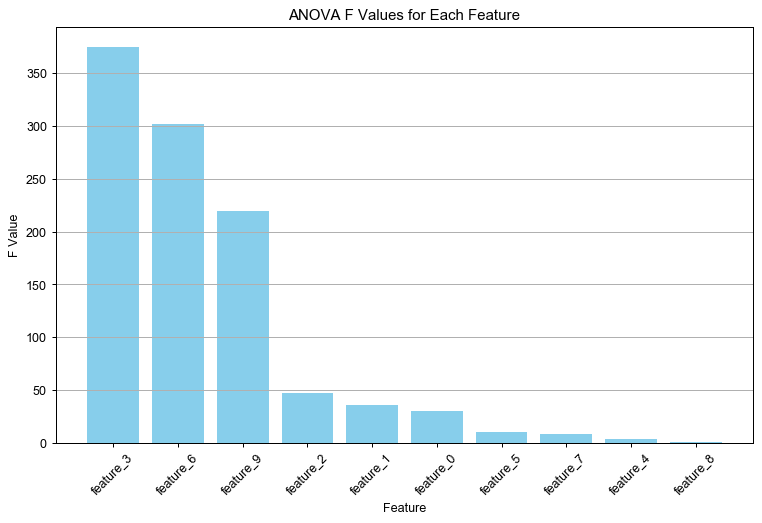

In [3]:
import pandas as pd
from sklearn.datasets import make_regression
from sklearn.feature_selection import f_regression, SelectKBest
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## 生成一个包含 1000 个样本和 10 个特征的回归数据集
X, y = make_regression(n_samples=1000, n_features=10, noise=10, random_state=42)
## 将数据转为 DataFrame 格式
df = pd.DataFrame(X, columns=['feature_' + str(i) for i in range(10)])
df['target'] = y

## 分割数据为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(df.drop('target', axis=1), df['target'], test_size=0.2, random_state=42)

## 对训练集进行 ANOVA F 检验
f_values, p_values = f_regression(X_train, y_train)
anova_results = pd.DataFrame({
    'Feature': X_train.columns,
    'F_value': f_values,
    'p_value': p_values
}).sort_values(by='F_value', ascending=False)

print("ANOVA F 检验结果:")
print(anova_results)

## 选择 p 值小于 0.05 的特征
selected_features = anova_results[anova_results['p_value'] < 0.05]['Feature'].tolist()
print("\n显著的特征:", selected_features)

## 利用筛选后的特征进行线性回归建模
model = LinearRegression()
model.fit(X_train[selected_features], y_train)
score = model.score(X_test[selected_features], y_test)
print("\n使用筛选后特征的模型 R^2 分数: {:.4f}".format(score))

## 可视化各特征的 F 值
plt.figure(figsize=(10, 6))
plt.bar(anova_results['Feature'], anova_results['F_value'], color='skyblue')
plt.xlabel('Feature')
plt.ylabel('F Value')
plt.title('ANOVA F Values for Each Feature')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

- **数据生成与预处理**：利用 `make_regression` 生成模拟数据，构造一个包含 10 个特征和目标变量的数据集，并将数据分为训练集与测试集。
- **F 检验**：调用 `f_regression` 对每个特征计算 F 值和 p 值，结果保存在 DataFrame 中进行展示。
- **特征筛选**：根据 p 值筛选出显著的特征（例如 p 值小于 0.05 的特征），从而作为后续模型训练的输入。
- **模型训练与评估**：利用线性回归模型训练，并计算模型在测试集上的 R² 分数，验证筛选特征的效果。
- **可视化**：绘制各特征 F 值的条形图，直观展示每个特征与目标变量的相关性。

![原文参考图，当前结果见代码输出](attachments/img_022.png)

这种方法可以帮助我们从大量特征中快速筛选出与目标变量关系最为显著的变量，为后续模型的构建提供可靠依据。

## 附录：F检验更数学推导

为了使对数学推导过程有更深入理解的读者能够进一步探索，我在此给出更详细的公式推导说明。

### 变量定义与基本分布

假设：

$U \sim \chi^2_{d_1}$的概率密度函数为  
$f_U(u) = \frac{1}{2^{d_1/2}\Gamma(d_1/2)} u^{d_1/2-1} e^{-u/2}, \quad u > 0,$

$V \sim \chi^2_{d_2}$的概率密度函数为  
$f_V(v) = \frac{1}{2^{d_2/2}\Gamma(d_2/2)} v^{d_2/2-1} e^{-v/2}, \quad v > 0.$

### 定义 F 统计量

令  
$F = \frac{U/d_1}{V/d_2},$  
则为了得到 $F$的分布，我们考虑构造联合分布 $f_{U,V}(u,v)$并利用变量变换求得 $f_F(x)$。

### 变量变换与联合分布

令  
$x = \frac{U/d_1}{V/d_2}, \quad v = v,$  
则有  
$U = x \frac{d_1}{d_2} v.$  
计算变换的雅可比行列式（Jacobian）后，可以写出新的联合概率密度函数 $f_{X,V}(x,v)$。积分掉 $v$后，即可得到 $x$的边缘密度函数。

### 利用伽玛函数进行积分

积分过程中会用到如下积分公式：


$$
\int_0^\infty v^{\alpha-1}e^{-\beta v}\,dv = \frac{\Gamma(\alpha)}{\beta^\alpha},
$$


将该公式代入后，并经过一系列化简，便能得出 F 分布的概率密度函数：


$$
f_F(x; d_1, d_2) = \frac{\Gamma\left(\frac{d_1+d_2}{2}\right)}{\Gamma\left(\frac{d_1}{2}\right)\Gamma\left(\frac{d_2}{2}\right)} \left(\frac{d_1}{d_2}\right)^{d_1/2} x^{d_1/2-1} \left(1+\frac{d_1}{d_2}x\right)^{-(d_1+d_2)/2}, \quad x>0.
$$


整个推导过程包括以下步骤：

1. 利用两个独立卡方变量的联合分布写出初始密度函数。
2. 进行变量变换，将原变量表达为 $(x, v)$。
3. 计算雅可比行列式，并写出新变量的联合密度函数。
4. 对 $v$进行积分，利用伽玛函数积分公式，得到 $x$的边缘分布。
5. 化简并整理，得出最终的 F 分布概率密度函数。

这一详细推导展示了 F 检验背后严谨的数学基础，有助于理解为什么 F 检验在比较样本方差时能够给出合理的统计推断。

F 检验作为统计学中一个基础而重要的检验方法，在各类科学研究和数据分析中都有广泛的应用。无论是在科研实验设计中比较两组数据的方差，还是在机器学习中进行特征选择与模型评估，F 检验都能发挥重要作用。